<a href="https://colab.research.google.com/github/danikpretor/statistical-processing-of-measurement-results/blob/main/Wafer_recalculated_U.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## Парсинг данных и содание DataFrame


1.  **Загрузка данных:** Читает данные о сопротивлении, Ueff и толщине из CSV-файлов для каждого номера пластины (от 1 до 20).
2.  **Обработка данных:** Объединяет данные по каждой пластине в отдельные DataFrame, затем объединяет все данные в один большой DataFrame (`factory_df`). При чтении файлов удаляет нулевые символы и преобразует данные в числа, пропуская некорректные значения. Берет каждое 5-е значение.
3.  **Сводная таблица:** Создает сводную таблицу (`summary_df`) с основными статистиками (среднее, стандартное отклонение, среднее отклонение) для каждой пластины на основе заводских данных.
4.  **Лабораторные данные:** Определяет DataFrame (`lab_data`) с лабораторными данными по толщине, удельному сопротивлению и отклонению толщины для каждой пластины.

По сути, этот блок подготавливает и объединяет заводские и лабораторные данные для последующего анализа и сравнения.

In [ ]:
import os
import pandas as pd
import numpy as np
from scipy import stats

# ------------------------
# 1. Функция расчёта среднего отклонения
# ------------------------
def calculate_average_deviation(values):
    mean = np.mean(values)
    return np.mean(np.abs(values - mean))

# ------------------------
# 2. Функция чтения CSV с очисткой
# ------------------------
def read_resistance_file(file_dir, name_file):
    file_path = os.path.join(file_dir, name_file)
    with open(file_path, 'r', encoding='utf-8') as file:
        content = file.read()
    cleaned_content = content.replace('\x00', '')
    all_values = cleaned_content.split(';')
    numeric_values = []
    for v in all_values:
        if v.strip():
            try:
                numeric_values.append(float(v))
            except ValueError:
                continue
    df_united = pd.DataFrame(numeric_values, columns=['value'])
    return df_united

# ------------------------
# 3. Читаем все данные с завода
# ------------------------
base_dir = '/content/drive/MyDrive/Colab Notebooks/Wafer 2'
wafer_numbers = [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20]
all_datasets = {}


for wafer_num in wafer_numbers:
    wafer_dir = os.path.join(base_dir, str(wafer_num))
    resistance_df = read_resistance_file(wafer_dir, 'resistance.csv')
    uef_v_df = read_resistance_file(wafer_dir, 'resistanceUeff.csv')
    thickness_files = ['thicknesscenter.csv', 'thicknessleft.csv', 'thicknessright.csv']
    thickness_data = [read_resistance_file(wafer_dir, f) for f in thickness_files]
    combined_thickness = pd.concat(thickness_data, ignore_index=True)

    resistance_values = resistance_df['value'].dropna().to_numpy()
    thickness_values = combined_thickness['value'].dropna().to_numpy()
    uef_v = uef_v_df['value'].dropna().to_numpy()

    min_len = min(len(resistance_values), len(thickness_values), len(uef_v))

    # берем каждое 10-е значение
    resistance_values = resistance_values[:min_len][::5]
    thickness_values = thickness_values[:min_len][::5]
    uef_v = uef_v[:min_len][::5]

    dataset = pd.DataFrame({
        'wafer': wafer_num,
        'resistance_ohm_cm': resistance_values,
        'thickness_um': thickness_values,
        'Uef_v': uef_v
    })
    all_datasets[wafer_num] = dataset


# Объединяем в один DataFrame
factory_df = pd.concat(all_datasets.values(), ignore_index=True)

# ------------------------
# 4. Сводная таблица по каждому номеру пластины
# ------------------------
summary_list = []
for wafer, df in all_datasets.items():
    summary = {
        'wafer': wafer,
        'mean_Uef_v': df['Uef_v'].mean(),
        'mean_thickness_um': df['thickness_um'].mean(),
        'std_thickness_um': df['thickness_um'].std(),
        'avg_deviation_thickness_um': calculate_average_deviation(df['thickness_um']),  # Среднее отклонение
        'mean_resistance': df['resistance_ohm_cm'].mean(),
        'std_resistance': df['resistance_ohm_cm'].std()
    }
    summary_list.append(summary)

summary_df = pd.DataFrame(summary_list)

# ------------------------
# 5. Данные лаборатории
# ------------------------
lab_data = pd.DataFrame({
    'wafer': [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20],
    'lab_thickness_um': [156.00, 155.96, 157.25, 154.27, 155.54, 155.08, 154.04, 130.79, 130.98, 130.68, 131.07, 131.21, 154.09, 141.31, 152.77, 152.78, 152.28, 152.18, 151.00, 155.19],
    'lab_resistivity_ohm_cm': [1.66, 1.69, 1.72, 1.30, 1.31, 1.31, 1.32, 2.09, 2.07, 1.41, 2.09, 2.12, 1.45, 1.24, 1.14, 1.20, 1.21, 1.21, 1.19, 1.18],
    'thickness_deviation': [12.72, 6.68, 6.51, 6.01, 4.54, 4.96, 6.49, 6.62, 4.83, 4.41, 3.62, 4.78, 5.99, 34.22, 6.66, 6.29, 4.03, 3.93, 4.43, 4.11]
})


## Расчёт сопротивления пластин с помощью новых коэффициентов

```python
K1_new = 79.799
K2_new = 0.014
```

## Расчёт сопротивления пластин с помощью новых коэффициентов

Этот блок кода выполняет перерасчёт сопротивления для всех заводских данных, используя новые коэффициенты `K1_new` и `K2_new`.

1.  **Определение функции `recalculate_resistance`**: Создается функция, которая принимает строку данных (`row`), `K1` и `K2` и рассчитывает сопротивление в Ом·см, используя формулу: `Rs = K1 / (Uef_v - K2)`, а затем `сопротивление (Ом·см) = Rs * (толщина в см)`.
2.  **Применение функции к заводским данным**: Функция `recalculate_resistance` применяется к каждой строке DataFrame `factory_df`, создавая новый столбец `recalculated_resistance` с пересчитанными значениями.
3.  **Обновление сводной таблицы**: Средние значения пересчитанного сопротивления группируются по номеру пластины и используются для обновления DataFrame `comparison`, который объединяет заводские и лабораторные данные.
4.  **Расчёт разницы и относительной ошибки**: Вычисляется абсолютная разница и относительная ошибка между пересчитанным заводским сопротивлением и лабораторным сопротивлением.
5.  **Фильтрация данных**: DataFrame `comparison` фильтруется, оставляя только те пластины, у которых относительная ошибка пересчитанного сопротивления меньше 2%.
6.  **Вывод сравнения**: Отображается таблица с номером пластины, пересчитанным заводским сопротивлением, лабораторным сопротивлением, абсолютной разницей и относительной ошибкой для отфильтрованных пластин.
7.  **Статистический анализ**: Проводится T-тест для сравнения средних значений пересчитанного заводского и лабораторного сопротивления, а также F-тест для сравнения дисперсий.
8.  **Интерпретация результатов**: Выводится сообщение о том, является ли различие в сопротивлении статистически значимым, а также средняя относительная ошибка.

По сути, этот блок кода оценивает, насколько хорошо пересчитанные заводские измерения сопротивления согласуются с лабораторными данными после применения новых калибровочных коэффициентов.

In [ ]:
# ------------------------
# 6. Перерасчёт сопротивлений
# ------------------------

# Коэффициенты для перерасчёта
K1_new = 79.799
K2_new = 0.014

# Функция для пересчёта сопротивления
def recalculate_resistance(row, K1, K2):
    Rs = K1 / (row['Uef_v'] - K2)
    resistance_ohm_cm = Rs * (row['thickness_um'] / 10000)  # Переводим толщину в см
    return resistance_ohm_cm

# Пересчитываем сопротивление для всех данных
factory_df['recalculated_resistance'] = factory_df.apply(
    lambda row: recalculate_resistance(row, K1_new, K2_new), axis=1
)

# Обновляем средние значения сопротивления для каждой пластины
recalculated_mean_resistance = factory_df.groupby('wafer')['recalculated_resistance'].mean()

comparison = pd.merge(summary_df, lab_data, on='wafer')

# Удаляем старый столбец, если он существует
if 'recalculated_mean_resistance' in comparison.columns:
    comparison = comparison.drop(columns=['recalculated_mean_resistance'])

# Обновляем `comparison` новыми средними значениями сопротивления,
# только для тех пластин, которые есть в `comparison`
comparison = comparison.join(
    recalculated_mean_resistance.rename('recalculated_mean_resistance'),
    on='wafer',
    how='left'
)

# Пересчитываем разницу и относительную ошибку
comparison['d_recalculated_resistance'] = np.abs(
    comparison['recalculated_mean_resistance'] - comparison['lab_resistivity_ohm_cm']
)

comparison['rel_error_recalculated_resistance_%'] = (
    100 * comparison['d_recalculated_resistance'] / comparison['lab_resistivity_ohm_cm']
)

# Фильтруем данные по относительной ошибке
comparison = comparison[comparison['rel_error_recalculated_resistance_%'] < 2]

# Выводим обновлённое сравнение
print("=== Сравнение с лабораторией после пересчёта и фильтрации ===")
comparison_recalculated = pd.DataFrame(
    comparison[['wafer', 'recalculated_mean_resistance', 'lab_resistivity_ohm_cm', 'd_recalculated_resistance', 'rel_error_recalculated_resistance_%']]
)

# Заменяем индекс на столбец 'wafer'
comparison_recalculated = comparison_recalculated.set_index('wafer')

# Выводим результат
print(comparison_recalculated)

# ------------------------
# 7.Делаем выводы, сравниваем значение с лабой. Лабораторные данные берем как истины (эталонные).
# ------------------------

# Статистический анализ
print("\n=== Статистический анализ после пересчёта и фильтрации ===")
# T-тест сопротивления
t_recalculated_res, p_recalculated_res = stats.ttest_rel(
    comparison['recalculated_mean_resistance'], comparison['lab_resistivity_ohm_cm']
)

# F-тест сопротивления (отношение дисперсий)
std_recalculated_resistance = factory_df.groupby('wafer')['recalculated_resistance'].std()
F_recalculated_res = (std_recalculated_resistance.max() ** 2) / (std_recalculated_resistance.min() ** 2)
print(f"T-test сопротивления: t={t_recalculated_res:.3f}, p={p_recalculated_res:.3f}")
print(f"F-test сопротивления (отношение дисперсий): F={F_recalculated_res:.3f}")

# Интерпретация результатов
if p_recalculated_res > 0.05:
    print("✅ Различие в сопротивлении статистически незначимо (оборудование согласуется с лабораторией).")
else:
    print("⚠️ Сопротивление отличается значимо (p<0.05). Проверьте коэффициенты пересчёта Rs→ρ.")

# Дополнительная статистика
print(f"\n=== Дополнительная статистика ===")
print(f"Средняя относительная ошибка сопротивления: {comparison['rel_error_recalculated_resistance_%'].mean():.2f}%")


=== Сравнение с лабораторией после пересчёта и фильтрации ===
       recalculated_mean_resistance  lab_resistivity_ohm_cm  \
wafer                                                         
1                          1.638661                    1.66   
2                          1.686371                    1.69   
3                          1.716380                    1.72   
8                          2.113033                    2.09   
9                          2.095377                    2.07   
10                         1.415533                    1.41   
11                         2.075954                    2.09   
12                         2.134886                    2.12   
13                         1.442988                    1.45   
16                         1.191339                    1.20   
17                         1.228465                    1.21   
18                         1.224967                    1.21   
19                         1.213344                    1

## Считаем повторяемость, относительную, по каждой пластине, и при 1-сигма

In [ ]:
# ------------------------
# 8. Относительная повторяемость
# ------------------------



# Получаем список номеров пластин (wafer), которые прошли фильтр
wafers_to_analyze = comparison['wafer'].unique()

# Фильтруем factory_df, чтобы оставить только данные для отобранных пластин
factory_df_filtered = factory_df[factory_df['wafer'].isin(wafers_to_analyze)].copy()

# Теперь рассчитываем повторяемость только на отфильтрованном наборе данных
print("\n                   = Расчёт повторяемости для пластин ==")

# Группировка по пластине
grouped_by_wafer_filtered = factory_df_filtered.groupby('wafer')['recalculated_resistance']

# Расчёт стандартного отклонения и среднего для каждой пластины
wafer_std_filtered = grouped_by_wafer_filtered.std()
wafer_mean_filtered = grouped_by_wafer_filtered.mean()

# Расчёт повторяемость для каждой пластины
wafer_relative_repeatability_filtered = wafer_std_filtered / wafer_mean_filtered

# Вычисление средней повторяемости по всем отобранным пластинам
mean_relative_repeatability = wafer_relative_repeatability_filtered.mean()


# === Вывод повторяемости по каждой пластинке ===

# Фильтруем factory_df только по пластинам, прошедшим фильтрацию (rel_error < 2%)
wafers_to_analyze = comparison['wafer'].unique()
factory_df_filtered = factory_df[factory_df['wafer'].isin(wafers_to_analyze)].copy()

# Группировка по пластине
grouped = factory_df_filtered.groupby('wafer')['recalculated_resistance']

# Считаем статистики
wafer_stats = pd.DataFrame({
    'n_measurements': grouped.count(),
    'mean_recalculated_resistance': grouped.mean(),
    'std_recalculated_resistance': grouped.std(),  # абсолютная повторяемость
    'relative_repeatability': grouped.std() / grouped.mean()  # относительная повторяемость (CV)
})

# Вывод результатов
print("\n=== Повторяемость по каждой пластине (после фильтрации) ===")

print(wafer_stats[['n_measurements', 'std_recalculated_resistance', 'relative_repeatability']])

# Опционально: форматировать relative_repeatability в процентах
wafer_stats['relative_repeatability_%'] = wafer_stats['relative_repeatability'] * 100
print("\nОтносительная повторяемость (%):")
for wafer, row in wafer_stats.iterrows():
    print(f"Пластина {wafer}: {row['relative_repeatability_%']:.2f}% (n={row['n_measurements']})")


# Сравнение с res_repeat
res_repeat = 0.02
if mean_relative_repeatability < res_repeat:
    print(f"✅ Результат повторяемости ({mean_relative_repeatability:.4f}) соответствует спецификации ({res_repeat}).")
else:
    print(f"⚠️ Результат повторяемости ({mean_relative_repeatability:.4f}) не соответствует спецификации ({res_repeat}).")


print(f"=== Расчёт общей повторяемости (1-сигма) ===")

# Веса = количество измерений на пластине - 1 (для несмещённой дисперсии)
grouped = factory_df_filtered.groupby('wafer')['recalculated_resistance']
variances = grouped.var()  # несмещённая дисперсия (ddof=1 по умолчанию)
counts = grouped.count()

# Общая внутригрупповая дисперсия (pooled variance)
pooled_variance = (variances * (counts - 1)).sum() / (counts.sum() - counts.count())
pooled_std = pooled_variance ** 0.5

# Для относительной повторяемости — нужно выбрать характерное среднее
# Например, среднее по всем данным или медиану средних по пластинам
overall_mean = factory_df_filtered['recalculated_resistance'].mean()
pooled_relative_repeatability = pooled_std / overall_mean

# Сравнение с res_repeat
res_repeat = 0.02
if pooled_relative_repeatability < res_repeat:
    print(f"✅ Результат повторяемости ({pooled_relative_repeatability:.4f}) соответствует спецификации ({res_repeat}).")
else:
    print(f"⚠️ Результат повторяемости ({pooled_relative_repeatability:.4f}) не соответствует спецификации ({res_repeat}).")



                   = Расчёт повторяемости для пластин ==

=== Повторяемость по каждой пластине (после фильтрации) ===
       n_measurements  std_recalculated_resistance  relative_repeatability
wafer                                                                     
1                 574                     0.060434                0.036880
2                 708                     0.050853                0.030155
3                 741                     0.044052                0.025665
8                 747                     0.036280                0.017170
9                 739                     0.052866                0.025230
10                720                     0.044355                0.031335
11                729                     0.059940                0.028873
12                742                     0.055539                0.026015
13                735                     0.030205                0.020932
16                632                     0.039745      

## Сравнение толщины

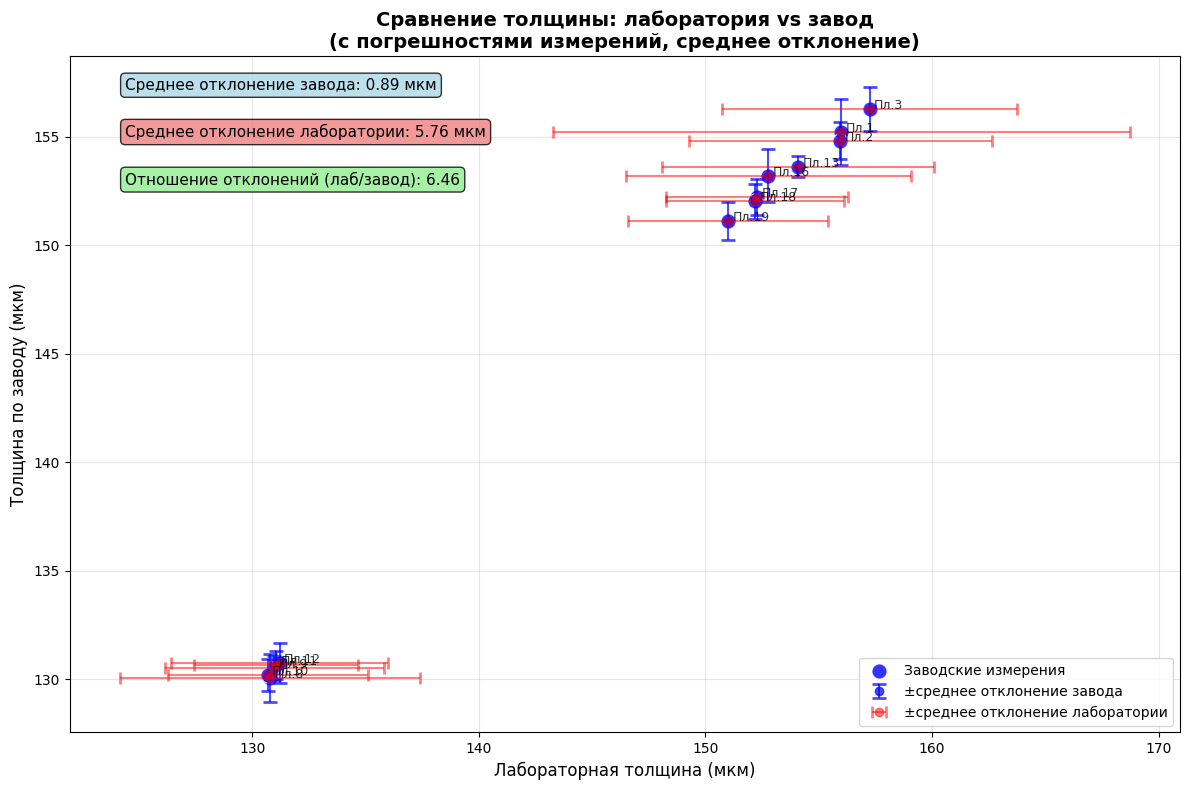


=== Сравнение погрешностей ===
Среднее отклонение завода: 0.892 мкм
Среднее отклонение лаборатории: 5.757 мкм
Отношение отклонений (лаб/завод): 6.46
Максимальное отклонение лаборатории: 12.720 мкм
Минимальное отклонение лаборатории: 3.620 мкм


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 8))

# Scatter plot
sns.scatterplot(
    data=comparison,
    x='lab_thickness_um',
    y='mean_thickness_um',
    s=120,
    color='blue',
    alpha=0.8,
    label='Заводские измерения'
)

# Error bars для ЗАВОДА (синие вертикальные, теперь используем avg_deviation_thickness_um)
plt.errorbar(
    comparison['lab_thickness_um'],
    comparison['mean_thickness_um'],
    yerr=comparison['avg_deviation_thickness_um'],
    fmt='o',
    color='blue',
    alpha=0.7,
    capsize=5,
    capthick=2,
    label='±среднее отклонение завода'
)

# Error bars для ЛАБОРАТОРИИ (красные горизонтальные)
plt.errorbar(
    comparison['lab_thickness_um'],
    comparison['mean_thickness_um'],
    xerr=comparison['thickness_deviation'],
    fmt='o',
    color='red',
    alpha=0.5,
    capsize=4,
    capthick=2,
    label='±среднее отклонение лаборатории'
)

# Добавляем аннотации с номерами пластин
for i, row in comparison.iterrows():
    plt.annotate(
        f"Пл.{int(row['wafer'])}",
        (row['lab_thickness_um'] + 0.2, row['mean_thickness_um']),
        fontsize=9,
        alpha=0.8
    )

plt.xlabel('Лабораторная толщина (мкм)', fontsize=12)
plt.ylabel('Толщина по заводу (мкм)', fontsize=12)
plt.title(
    'Сравнение толщины: лаборатория vs завод\n(с погрешностями измерений, среднее отклонение)',
    fontsize=14,
    fontweight='bold'
)

plt.legend()
plt.grid(True, alpha=0.3)

# Добавляем статистику погрешностей
mean_factory_avg_deviation = comparison['avg_deviation_thickness_um'].mean()
mean_lab_avg_deviation = comparison['thickness_deviation'].mean()

plt.text(
    0.05, 0.95,
    f'Среднее отклонение завода: {mean_factory_avg_deviation:.2f} мкм',
    transform=plt.gca().transAxes,
    fontsize=11,
    bbox=dict(boxstyle="round,pad=0.3", facecolor="lightblue", alpha=0.8)
)

plt.text(
    0.05, 0.88,
    f'Среднее отклонение лаборатории: {mean_lab_avg_deviation:.2f} мкм',
    transform=plt.gca().transAxes,
    fontsize=11,
    bbox=dict(boxstyle="round,pad=0.3", facecolor="lightcoral", alpha=0.8)
)

plt.text(
    0.05, 0.81,
    f'Отношение отклонений (лаб/завод): {mean_lab_avg_deviation/mean_factory_avg_deviation:.2f}',
    transform=plt.gca().transAxes,
    fontsize=11,
    bbox=dict(boxstyle="round,pad=0.3", facecolor="lightgreen", alpha=0.8)
)

plt.tight_layout()
plt.show()

# Дополнительная статистика
print("\n=== Сравнение погрешностей ===")
print(f"Среднее отклонение завода: {mean_factory_avg_deviation:.3f} мкм")
print(f"Среднее отклонение лаборатории: {mean_lab_avg_deviation:.3f} мкм")
print(f"Отношение отклонений (лаб/завод): {mean_lab_avg_deviation/mean_factory_avg_deviation:.2f}")
print(f"Максимальное отклонение лаборатории: {comparison['thickness_deviation'].max():.3f} мкм")
print(f"Минимальное отклонение лаборатории: {comparison['thickness_deviation'].min():.3f} мкм")


## Сравнение сопротивления
Сравниваются значение сопротивления измеренные и перерасчитанные из U c Lab

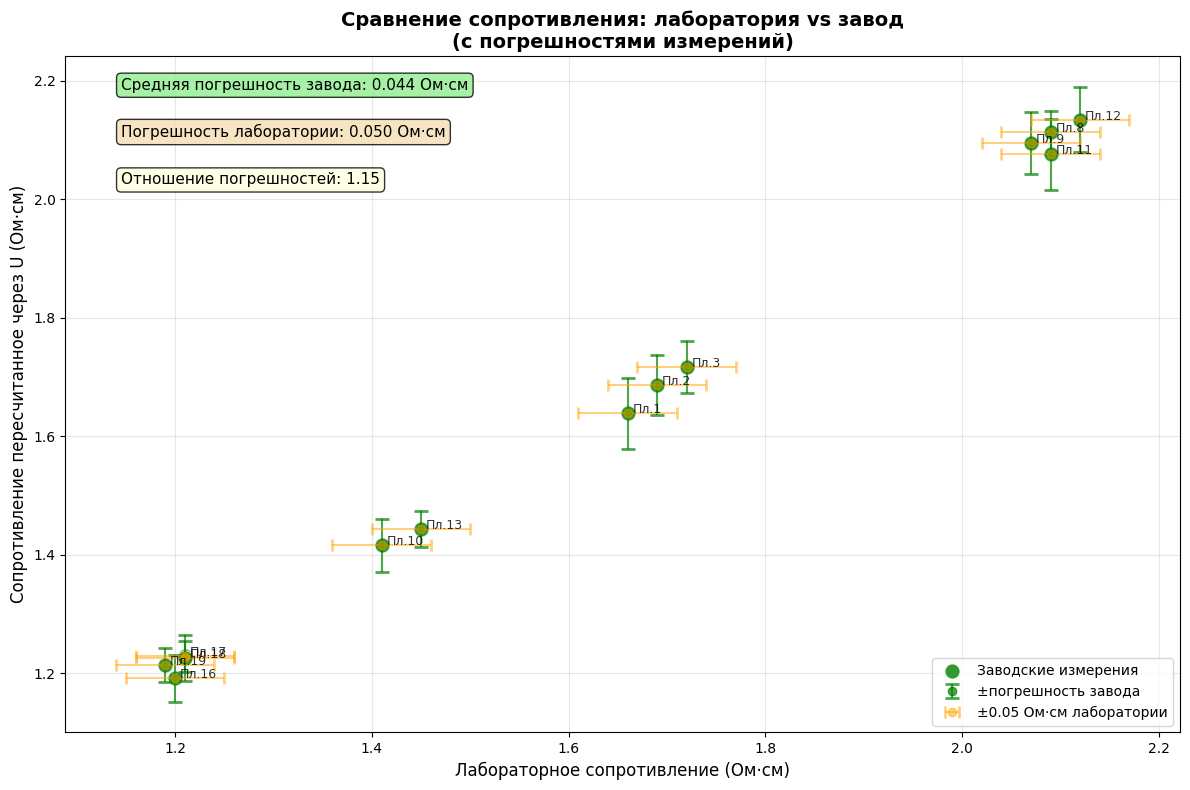

In [ ]:
# --- График сравнение сопротивления с погрешностями ---


plt.figure(figsize=(12, 8))
# Scatter plot для сопротивления
sns.scatterplot(
    data=comparison,
    x='lab_resistivity_ohm_cm',
    y='recalculated_mean_resistance',
    s=120,
    color='green',
    alpha=0.8,
    label='Заводские измерения'
)
# Отфильтруем std_recalculated_resistance по тем же wafer, что и в comparison
filtered_std_resistance = std_recalculated_resistance[std_recalculated_resistance.index.isin(comparison['wafer'])]
# Error bars для ЗАВОДА (зеленые вертикальные, filtered_std_resistance)
plt.errorbar(
    comparison['lab_resistivity_ohm_cm'],
    comparison['recalculated_mean_resistance'],
    yerr=filtered_std_resistance.values,
    fmt='o',
    color='green',
    alpha=0.7,
    capsize=5,
    capthick=2,
    label='±погрешность завода'
)
# Error bars для ЛАБОРАТОРИИ (оранжевые горизонтальные)
lab_resistance_error = 0.05  # Предполагаемая погрешность лаборатории
plt.errorbar(
    comparison['lab_resistivity_ohm_cm'],
    comparison['recalculated_mean_resistance'],
    xerr=lab_resistance_error,
    fmt='o',
    color='orange',
    alpha=0.5,
    capsize=4,
    capthick=2,
    label=f'±{lab_resistance_error} Ом·см лаборатории'
)
# Добавляем аннотации с номерами пластин
for i, row in comparison.iterrows():
    plt.annotate(
        f"Пл.{int(row['wafer'])}",
        (row['lab_resistivity_ohm_cm'] + 0.005, row['recalculated_mean_resistance']),
        fontsize=9,
        alpha=0.8
    )
plt.xlabel('Лабораторное сопротивление (Ом·см)', fontsize=12)
plt.ylabel('Сопротивление пересчитанное через U (Ом·см)', fontsize=12)
plt.title(
    'Сравнение сопротивления: лаборатория vs завод\n(с погрешностями измерений)',
    fontsize=14,
    fontweight='bold'
)
plt.legend()
plt.grid(True, alpha=0.3)
# Добавляем статистику
mean_factory_res_error = filtered_std_resistance.mean()
plt.text(
    0.05, 0.95,
    f'Средняя погрешность завода: {mean_factory_res_error:.3f} Ом·см',
    transform=plt.gca().transAxes,
    fontsize=11,
    bbox=dict(boxstyle="round,pad=0.3", facecolor="lightgreen", alpha=0.8)
)
plt.text(
    0.05, 0.88,
    f'Погрешность лаборатории: {lab_resistance_error:.3f} Ом·см',
    transform=plt.gca().transAxes,
    fontsize=11,
    bbox=dict(boxstyle="round,pad=0.3", facecolor="wheat", alpha=0.8)
)
plt.text(
    0.05, 0.81,
    f'Отношение погрешностей: {lab_resistance_error/mean_factory_res_error:.2f}',
    transform=plt.gca().transAxes,
    fontsize=11,
    bbox=dict(boxstyle="round,pad=0.3", facecolor="lightyellow", alpha=0.8)
)
plt.tight_layout()
plt.show()


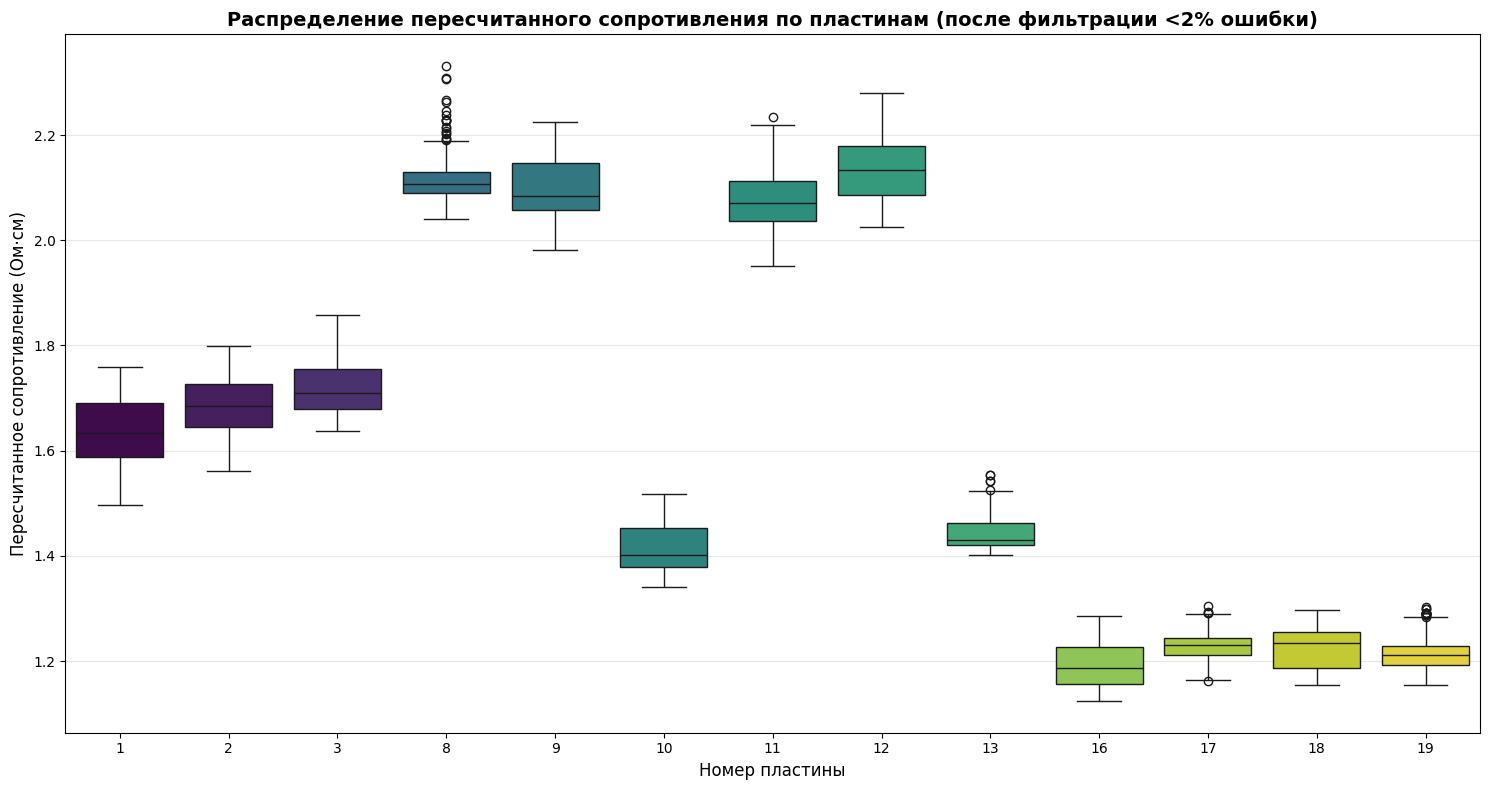

In [ ]:
# --- Boxplot сопротивления по пластинам (после фильтрации) ---
plt.figure(figsize=(15, 8))
sns.boxplot(
    data=factory_df_filtered,
    x='wafer',
    y='recalculated_resistance',
    hue='wafer',  # Указываем hue
    palette='viridis',
    legend=False # Отключаем легенду, так как hue соответствует x
)

plt.xlabel('Номер пластины', fontsize=12)
plt.ylabel('Пересчитанное сопротивление (Ом·см)', fontsize=12)
plt.title(
    'Распределение пересчитанного сопротивления по пластинам (после фильтрации <2% ошибки)',
    fontsize=14,
    fontweight='bold'
)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

In [ ]:

# Расчёт коэффициента корреляции Пирсона для сопротивления
corr_res = comparison['mean_resistance'].corr(comparison['lab_resistivity_ohm_cm'], method='pearson')
print(f"Коэффициент корреляции (r) для сопротивления = {corr_res:.4f}")

'''
Толкование результата

- r ≈ 1 — сильная положительная корреляция (данные совпадают по тренду)
- r ≈ 0 — отсутствует линейная зависимость
- r ≈ -1 — сильная отрицательная корреляция
'''

Коэффициент корреляции (r) для сопротивления = 0.9852


'\nТолкование результата\n\n- r ≈ 1 — сильная положительная корреляция (данные совпадают по тренду)\n- r ≈ 0 — отсутствует линейная зависимость\n- r ≈ -1 — сильная отрицательная корреляция\n'

## Повторяемость при 1σ

In [ ]:

sigma = 1

# Применяем фильтрацию по 3 сигма внутри каждой пластины
factory_df['recalibrated_clean'] = factory_df.groupby('wafer')['recalculated_resistance'].transform(
    lambda x: x.where((x >= x.mean() - sigma * x.std()) & (x <= x.mean() + sigma * x.std()))
)

# Удаляем строки с выбросами (они стали NaN)
factory_df_clean = factory_df.dropna(subset=['recalibrated_clean']).copy()

# Теперь используем очищенные данные для всех дальнейших расчётов
factory_df_clean['recalculated_resistance'] = factory_df_clean['recalibrated_clean']
factory_df_clean = factory_df_clean.drop(columns=['recalibrated_clean'])

# Пересчитываем средние значения сопротивления для каждой пластины (на очищенных данных!)
recalculated_mean_resistance = factory_df_clean.groupby('wafer')['recalculated_resistance'].mean()

# ... и далее везде используем factory_df_clean вместо factory_df

# Фильтруем по пластинам, прошедшим сравнение с лабораторией
wafers_to_analyze = comparison['wafer'].unique()
factory_df_final = factory_df_clean[factory_df_clean['wafer'].isin(wafers_to_analyze)].copy()

# Повторяемость по каждой пластине (уже на данных без выбросов!)
grouped = factory_df_final.groupby('wafer')['recalculated_resistance']
repeatability_per_wafer = pd.DataFrame({
    'n_measurements': grouped.count(),
    'mean_resistance': grouped.mean(),
    'std_resistance': grouped.std(),
    'relative_repeatability': grouped.std() / grouped.mean()
}).dropna()  # на случай, если после фильтрации осталось <2 точек

print(f"\n=== Повторяемость по пластинам (после удаления выбросов ±{sigma}σ), среднее {repeatability_per_wafer['relative_repeatability'].mean():.2f} ===")
print(repeatability_per_wafer[['n_measurements', 'std_resistance', 'relative_repeatability']])


=== Повторяемость по пластинам (после удаления выбросов ±1σ), среднее 0.02 ===
       n_measurements  std_resistance  relative_repeatability
wafer                                                        
1                 340        0.035955                0.022001
2                 447        0.029280                0.017366
3                 440        0.026752                0.015631
8                 555        0.018610                0.008818
9                 451        0.030113                0.014428
10                453        0.026464                0.018813
11                469        0.029043                0.014031
12                471        0.035938                0.016857
13                531        0.015946                0.011124
16                384        0.024695                0.020807
17                486        0.012558                0.010210
18                425        0.021703                0.017591
19                488        0.014858               

Let's break down the line of code:

## Сравнение с TTV

In [ ]:
# -----------------------------------
# 1 Параметры измерения сопротивления
# -----------------------------------
# Диапазон 0,1-10 Ом*см

res_accuracy = 1 #Точность 1%
res_repeat = 0.02 # Повторяемость 1-сигма относительная

# -----------------------------
# 2 Параметры измерения толщины
# -----------------------------

thick_average_accuracy = 1 # 1мкм
thick_repeat = 1 # 1мкм 1-сигма
thick_repeat_ttv = 1 # 1мкм 1-сигма
